# Diagrama UML

books
- id (PK)
- title
- url
- price
- rating (1–5)
- stock (0–1)
- description
- category_id (FK → categories.id)

authors
- id (PK)
- name (UNIQUE)

book_author
- book_id (FK → books.id)
- author_id (FK → authors.id)

categories
- id (PK)
- name (UNIQUE)

![alt text](image-1.png)

In [47]:
from bs4 import BeautifulSoup
import requests
from urllib.parse import urljoin
import json, os, time, re, sys



# Cambio por url de pagina 1 para despues ir cambiando a cada pagina
BASE = "https://books.toscrape.com/"
url = urljoin(BASE, "catalogue/page-1.html")
next_page = url



rating_number = {"One":1,"Two":2,"Three":3,"Four":4,"Five":5}
items = []


OPENLIB_SEARCH = "https://openlibrary.org/search.json"
GOOGLE_BOOKS = "https://www.googleapis.com/books/v1/volumes"

# funcion para obtener autores usando Open Library y Google Books
def get_authors(title, category, lang="en", timeout=1, max_authors=3):
    """
    Devuelve una LISTA de autores usando Open Library y como fallback Google Books.
    Siempre retorna al menos ["Desconocido"] si no encuentra nada.
    """
    def _norm(name: str) -> str:
        return re.sub(r"\s+", " ", name).strip()

    autores = []

    # 1) Open Library (puede traer múltiples)
    try:
        ol = requests.get(
            "https://openlibrary.org/search.json",
            params={"title": title, "limit": 3},
            timeout=timeout
        )
        ol.raise_for_status()
        docs = ol.json().get("docs", [])
        for d in docs:
            for a in d.get("author_name", []) or []:
                a = _norm(a)
                if a and a not in autores:
                    autores.append(a)
                    if len(autores) >= max_authors:
                        break
            if len(autores) >= max_authors:
                break
    except requests.RequestException as e:
        print(f"[⚠️] OpenLibrary error: {e}")

    # 2) Google Books (fallback, agrega si faltan)
    if len(autores) < max_authors:
        query = f'intitle:"{title}"'
        if category:
            query += f' subject:"{category}"'
        try:
            gb = requests.get(
                "https://www.googleapis.com/books/v1/volumes",
                params={
                    "q": query,
                    "maxResults": 3,
                    "orderBy": "relevance",
                    "langRestrict": lang
                },
                timeout=timeout
            )
            gb.raise_for_status()
            items = gb.json().get("items", []) or []
            for it in items:
                for a in it.get("volumeInfo", {}).get("authors", []) or []:
                    a = _norm(a)
                    if a and a not in autores:
                        autores.append(a)
                        if len(autores) >= max_authors:
                            break
                if len(autores) >= max_authors:
                    break
        except requests.RequestException as e:
            print(f"[⚠️] Google Books error: {e}")

    return autores if autores else ["Desconocido"]


# funcion para obtener el soup de una pagina o una url
def get_soup(url_pagina_soup):
    for intento in range(5):  # 🔹 ADICIÓN: reintentos
        try:
            resp = requests.get(url_pagina_soup, timeout=20)
            resp.raise_for_status()
            return BeautifulSoup(resp.text, "lxml")
        except requests.RequestException as e:
            print(f"[WARN] Falló {url_pagina_soup} (intento {intento+1}): {e}")
            time.sleep(0.5)
    raise RuntimeError(f"No pude obtener {url_pagina_soup}")



# mientras existan paginas siguientes, veridicado por boton next. otra forma de hacerlo es iterando
while next_page:

    soup = get_soup(next_page)
    books = soup.find_all("article", class_="product_pod")

    for b in books:


        # Title
        title = b.h3.a["title"]


        # Price
        # 💥💥💥 
        txtprice = b.find("p", class_="price_color").get_text(strip=True)
        price = float(re.sub(r"[^\d.]", "", txtprice))


        # URL
        href = b.h3.a["href"]
        book_url = urljoin(next_page, href)

        try:
            # detalle 
            soup_detail = get_soup(book_url)
        except RuntimeError as e:
            print(f"[SKIP] No pude abrir detalle: {book_url} -> {e}")
            continue   

        # category
        breadcrumb_link = soup_detail.select("ul.breadcrumb li a")
        category = breadcrumb_link[-1].get_text(strip=True) if len(breadcrumb_link) >= 3 else "Unknown"


        # Rating                   
        rating_tag = soup_detail.select_one("p.star-rating")
        classes = rating_tag.get("class", []) if rating_tag else []                        
        rating_word = next((c for c in classes if c in rating_number), "One")
        rating = rating_number.get(rating_word, 1)                         


        # Stock
        stock_text = soup_detail.find("p", class_="instock availability").get_text(strip=True)
        stock_text = stock_text.lower().replace(" ", "")
        stock = int(1 if "instock" in stock_text else 0)



        # description
        description_tag = soup_detail.find("div", id="product_description")
        description = (
            description_tag.find_next_sibling('p').text.strip()
            if description_tag else None
        )


        # 🔹 ADICIÓN (llamar API): buscar autores por título
        # Explicación:
        # - Usamos la función get_autor(title, category).
        # - Retorna una lista [] con los nombres de los autores o Desconocido.
        # - Se agrega como campo "author" en el item para persistirlo luego en JSON.
        authors = get_authors(title, category)
        # Pequeña pausa de cortesía para no saturar la API si hay muchos libros
        time.sleep(0.15)

        items.append({
            "title": title,
            "category": category,
            "rating": rating,
            "URL": book_url,
            "price": price,
            "stock": stock,
            "description": description,
            # 🔹 ADICIÓN (nuevo campo en el dataset): autores como lista
            # Explicación:
            # - Este campo nuevo te permitirá luego crear tablas 'autores' y 'libro_autor' (M:N) en tu DB.
            # - Mantenerlo como lista te conserva todos los coautores que reporte la API.
            "authors": authors
        })
        print(items)

    # para cada pagina del 1 al 5
    botton_next = soup.find("li", class_="next")
    if botton_next:
        href_next = botton_next.a["href"]
        next_page = urljoin(next_page, href_next)
        time.sleep(0.15)
    else:
        break


# Guardar en JSON
with open('libros_scrapeados.json', 'w', encoding='utf-8') as f:
    json.dump(items, f, ensure_ascii=False, indent=2)

# Leer desde JSON
with open('libros_scrapeados.json', 'r', encoding='utf-8') as f:
    datos = json.load(f)
    print(f'Se guardaron {len(datos)} libros')
    print(datos[0])  # Mostrar el primero para validar estructura

# Abrir automáticamente el archivo (solo en Windows)
os.startfile('libros_scrapeados.json')


[WARN] Falló https://books.toscrape.com/catalogue/page-1.html (intento 1): HTTPSConnectionPool(host='books.toscrape.com', port=443): Read timed out. (read timeout=20)
[WARN] Falló https://books.toscrape.com/catalogue/page-1.html (intento 2): HTTPSConnectionPool(host='books.toscrape.com', port=443): Read timed out. (read timeout=20)
[WARN] Falló https://books.toscrape.com/catalogue/page-1.html (intento 3): HTTPSConnectionPool(host='books.toscrape.com', port=443): Max retries exceeded with url: /catalogue/page-1.html (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000014D033CE5D0>: Failed to resolve 'books.toscrape.com' ([Errno 11001] getaddrinfo failed)"))
[WARN] Falló https://books.toscrape.com/catalogue/page-1.html (intento 4): HTTPSConnectionPool(host='books.toscrape.com', port=443): Max retries exceeded with url: /catalogue/page-1.html (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x0000014D033CDF90>: Failed to resolve

RuntimeError: No pude obtener https://books.toscrape.com/catalogue/page-1.html

#### para limpiar autores con nombres raros y que no son autores

In [6]:
import json, re
from pathlib import Path
from difflib import SequenceMatcher

JSON_PATH = "libros_scrapeados.json"

# 🔹 Palabras que suelen indicar que NO es una persona
BAD_TOKENS = {
    "books", "press", "university", "institute", "guides", "classics",
    "editors", "narrator", "study", "summary", "workbook", "comics",
    "publisher", "worth books"
}

# 🔹 Correcciones manuales de nombres frecuentes
CANON_MAP = {
    "eckart tolle": "Eckhart Tolle",
    "hg wells": "H. G. Wells",
    "h.g.wells": "H. G. Wells",
    "janice y k lee": "Janice Y. K. Lee",
}

# --- Funciones auxiliares ---
def similar(a: str, b: str) -> float:
    """Devuelve una puntuación de similitud (0 a 1) entre dos textos."""
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

def looks_like_person(name: str) -> bool:
    """Heurísticas para detectar si un texto parece nombre de persona."""
    s = name.strip()
    if not s or len(s) < 2:
        return False
    low = s.lower()
    if any(tok in low for tok in BAD_TOKENS):
        return False
    if re.fullmatch(r"[A-Z0-9\s\.\-]+", s) and s.isupper():
        return False
    # al menos un espacio o punto (iniciales)
    if " " not in s and "." not in s and len(s) < 4:
        return False
    return True

def canon_name(name: str) -> str:
    """Normaliza formato del nombre."""
    n = re.sub(r"\s+", " ", name).strip()
    key = n.lower()
    if key in CANON_MAP:
        return CANON_MAP[key]
    # Espaciado en iniciales, ejemplo: "H.G.Wells" → "H. G. Wells"
    n = re.sub(r"(?<=\w)\.(?=\w)", ". ", n)
    n = re.sub(r"\s+", " ", n)
    # Capitaliza palabras normales
    parts = []
    for p in n.split():
        if p.isupper() and len(p) <= 3:  # iniciales
            parts.append(p)
        else:
            parts.append(p.capitalize())
    return " ".join(parts)

# --- Limpieza principal ---
def limpiar_json(json_path=JSON_PATH, rewrite=True):
    data = json.loads(Path(json_path).read_text(encoding="utf-8"))
    cambios = 0

    for item in data:
        title = item.get("title", "").strip()
        autores = item.get("authors", [])
        nuevos = []

        for a in autores:
            if not isinstance(a, str):
                continue
            a = a.strip()
            if not a:
                continue
            # descartar si el autor es muy parecido al título
            if similar(a, title) > 0.8:
                continue
            # descartar si no parece persona
            if not looks_like_person(a):
                continue
            nuevos.append(canon_name(a))

        # si queda vacío, colocamos 'Desconocido'
        if not nuevos:
            nuevos = ["Desconocido"]

        # eliminar duplicados preservando orden
        vistos = set()
        finales = []
        for n in nuevos:
            key = n.lower()
            if key not in vistos:
                vistos.add(key)
                finales.append(n)

        if finales != autores:
            item["authors"] = finales
            cambios += 1

    if rewrite:
        Path(json_path).write_text(
            json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8"
        )
    print(f"Registros modificados: {cambios}")

# --- Ejecutar ---
if __name__ == "__main__":
    limpiar_json()


Registros modificados: 0


In [40]:
import sqlite3

# 1. Conectamos con la base
# conn representa la conexión a la base de datos.
conn = sqlite3.connect("libros.db")
cursor = conn.cursor()


# 2. Activamos las llaves foráneas (para relaciones entre tablas)
conn.execute("PRAGMA foreign_keys = ON;")   # PRAGMA es una directiva especial de SQLite para configurar opciones




# 3. Escribimos el DDL (definición de tablas)
DDL = """
CREATE TABLE IF NOT EXISTS categories (
    id      INTEGER PRIMARY KEY,
    name    TEXT NOT NULL UNIQUE
);

CREATE TABLE IF NOT EXISTS authors (
    id      INTEGER PRIMARY KEY,
    name    TEXT NOT NULL UNIQUE
);

CREATE TABLE IF NOT EXISTS books (
    id          INTEGER PRIMARY KEY,
    title       TEXT NOT NULL,
    url         TEXT NOT NULL UNIQUE,
    price       REAL NOT NULL,
    rating      INTEGER NOT NULL CHECK (rating BETWEEN 1 AND 5),
    stock       INTEGER NOT NULL CHECK (stock IN (0,1)),
    description TEXT,
    category_id INTEGER NOT NULL,
    FOREIGN KEY (category_id) REFERENCES categories(id) ON DELETE RESTRICT
);

CREATE TABLE IF NOT EXISTS book_author (
    book_id   INTEGER NOT NULL,
    author_id INTEGER NOT NULL,
    PRIMARY KEY (book_id, author_id),
    FOREIGN KEY (book_id)   REFERENCES books(id)   ON DELETE CASCADE,
    FOREIGN KEY (author_id) REFERENCES authors(id) ON DELETE CASCADE
);
"""

# on delete restrict y on delete cascade

# 4. Ejecutamos todas las sentencias
conn.executescript(DDL)

print("✅ Tablas creadas correctamente")

conn.close()


✅ Tablas creadas correctamente


In [41]:
import sqlite3
conn = sqlite3.connect("libros.db")
cursor = conn.cursor()

#Ver que las tablas se crearon
# SELECT sirve para seleccionar datos de una base de datos
# FROM es para especificar la tabla de donde se obtienen los datos
# sqlite_master es una tabla interna que guarda la estructura de la base
# WHERE sirve para filtrar los resultados
# type='table' filtra solo las filas que representan tablas
cursor.execute('''SELECT name FROM sqlite_master WHERE type='table' ''')
# fetchall() obtiene todas las filas del resultado de la consulta
# fetchall() trae una tupla de todas las filas de la tabla o de la base de datos
tablas = cursor.fetchall()

print("Tablas en la base de datos: ")
print(tablas)

conn.close()

Tablas en la base de datos: 
[('categories',), ('authors',), ('books',), ('book_author',)]


In [10]:
import sqlite3, json
from pathlib import Path

DB_PATH = "libros.db"              # cambia si tu DB se llama distinto
JSON_PATH = "libros_scrapeados.json"  # cambia si tu JSON se llama distinto

def cargar_categorias(db_path=DB_PATH, json_path=JSON_PATH):

    # 1. Cargar JSON
    data = json.loads(Path(JSON_PATH).read_text(encoding="utf-8"))
    print(f"Leídos {len(data)} libros desde el JSON ✅ \n")

    # 2. Conexión + FK on
    conn = sqlite3.connect(db_path)
    conn.execute("PRAGMA foreign_keys = ON;")
    cur = conn.cursor()

    # 3. recopilar categorías del JSON
    categorias = { item.get("category") for item in data if item.get("category") }
    print(f"categorías : {categorias}")

    # 4. Insertar en la tabla categories
    cur.executemany( "INSERT OR IGNORE INTO categories(name) VALUES (?);", [(c,) for c in sorted(categorias)])

    # 5. Guardar cambios
    conn.commit()

    # 6. Comprobar el resultado
    total = cur.execute("SELECT COUNT(*) FROM categories;").fetchone()[0]
    print(f"Listo categorías. Total en tabla: {total}")
    conn.close()

# Ejecutar solo este paso primero
cargar_categorias()


Leídos 1000 libros desde el JSON ✅ 

categorías : {'Young Adult', 'Fantasy', 'Contemporary', 'Christian Fiction', 'Spirituality', 'Womens Fiction', 'Fiction', 'New Adult', 'Autobiography', 'Travel', 'Business', 'Childrens', 'Humor', 'Philosophy', 'History', 'Short Stories', 'Music', 'Novels', 'Biography', 'Crime', 'Cultural', 'Academic', 'Historical Fiction', 'Historical', 'Nonfiction', 'Adult Fiction', 'Paranormal', 'Mystery', 'Food and Drink', 'Psychology', 'Romance', 'Classics', 'Science', 'Science Fiction', 'Religion', 'Politics', 'Add a comment', 'Default', 'Christian', 'Poetry', 'Sports and Games', 'Horror', 'Health', 'Suspense', 'Self Help', 'Art', 'Sequential Art', 'Parenting', 'Erotica', 'Thriller'}
Listo categorías. Total en tabla: 50


In [11]:
import sqlite3, json
from pathlib import Path

DB_PATH = "libros.db"
JSON_PATH = "libros_scrapeados.json"

def cargar_authors(db_path=DB_PATH, json_path=JSON_PATH):
    # 1) Leer JSON -> Python
    data = json.loads(Path(json_path).read_text(encoding="utf-8"))

    # 2) Conexión y FK ON
    conn = sqlite3.connect(db_path)
    conn.execute("PRAGMA foreign_keys = ON;")
    cur = conn.cursor()

    # 3) Deduplicar autores (siempre lista)
    autores = set()
    for item in data:
        for nm in item["authors"]:
            autores.add(str(nm).strip())

    # 4) Insert masivo sin duplicar en DB
    cur.executemany(
        "INSERT OR IGNORE INTO authors(name) VALUES (?);",
        [(a,) for a in sorted(autores)]
    )

    # 5) Confirmar y mostrar total
    conn.commit()
    total = cur.execute("SELECT COUNT(*) FROM authors;").fetchone()[0]
    print(f"Listo autores. Total en tabla: {total}")
    conn.close()

# Ejecutar
cargar_authors()


Listo autores. Total en tabla: 867


In [42]:
import sqlite3, json
from pathlib import Path

DB_PATH = "libros.db"
JSON_PATH = "libros_scrapeados.json"



def cargar_books(db_path=DB_PATH, json_path=JSON_PATH):
    data = json.loads(Path(json_path).read_text(encoding="utf-8"))
    conn = sqlite3.connect(db_path)
    conn.execute("PRAGMA foreign_keys = ON;")
    cur = conn.cursor()

    # 1) Obtener mapa categoría nombre->id
    # Precache de categorías name->id para acelerar
    cat_map = dict(cur.execute("SELECT name, id FROM categories;").fetchall())

    # 2) Sentencia de inserción
    insert_sql = """
    INSERT OR IGNORE INTO books(title, url, price, rating, stock, description, category_id)
    VALUES (?, ?, ?, ?, ?, ?, ?);
    """

    # 3) Preparar filas
    filas = []
    for it in data:
        cat = it.get("category")
        cat_id = cat_map.get(cat)

        # Agregar fila, en tupla para la tabla
        # Cada tupla representa una fila a insertar
        filas.append((
            it.get("title"),
            it.get("URL"),
            float(it.get("price") or 0.0),
            int(it.get("rating") or 0),
            int(it.get("stock") or 0),
            it.get("description"),
            cat_id
        ))
        # print(f"Preparando libro: {it.get('title')} (cat_id={cat_id})")

    # 4) Insertar todo
    cur.executemany(insert_sql, filas)
    conn.commit()



    # 5) Confirmar y mostrar total
    total = cur.execute("SELECT COUNT(*) FROM books;").fetchone()[0]
    print(f"Listo books. Total en tabla: {total}")
    conn.close()

# Ejecuta esto como tercer paso
cargar_books()


Listo books. Total en tabla: 1000


In [14]:
import sqlite3, json
from pathlib import Path

DB_PATH = "libros.db"
JSON_PATH = "libros_scrapeados.json"

def cargar_book_author(db_path=DB_PATH, json_path=JSON_PATH):
    data = json.loads(Path(json_path).read_text(encoding="utf-8"))

    conn = sqlite3.connect(db_path)
    conn.execute("PRAGMA foreign_keys = ON;")
    cur = conn.cursor()


    # 1) obtener mapas libro -> id y autor -> id
    # Cache: url libro -> id
    book_map = dict(cur.execute("SELECT url, id FROM books;").fetchall())
    # Cache: autor -> id
    author_map = dict(cur.execute("SELECT name, id FROM authors;").fetchall())


    # 2) sentencia inserción
    insert_rel = "INSERT OR IGNORE INTO book_author(book_id, author_id) VALUES (?, ?);"

    n_rel = 0
    # 3) recorrer datos del JSON 
    for it in data:
        # 4) obtener book_id por URL
        url = it.get("URL")
        book_id = book_map.get(url)

        # 5) obtener lista de autores
        autores = it.get("authors") or []

        # 6) iterar autores 
        for a in autores:
            # limpiar nombre
            a = str(a).strip()
            # obtener author_id
            a_id = author_map.get(a)

            # insertar relación
            cur.execute(insert_rel, (book_id, a_id))
            n_rel += 1

    # 7) confirmar y mostrar totales
    conn.commit()
    total_rel = cur.execute("SELECT COUNT(*) FROM book_author;").fetchone()[0]
    print(f"Listo relaciones. Agregadas ahora: {n_rel}. Total en tabla: {total_rel}")
    conn.close()

# Ejecuta esto como cuarto paso
cargar_book_author()


Listo relaciones. Agregadas ahora: 1499. Total en tabla: 1499


# Consultas

In [15]:
import sqlite3, pandas as pd
def run(sql, params=()):
    conn = sqlite3.connect("libros.db")
    display(pd.read_sql_query(sql, conn, params=params))
    conn.close()


In [43]:
# 1. Libros con más de 3 estrellas y a menos de £12
%time
query = """
SELECT title, price, rating
FROM books
WHERE rating > 3 AND price < 12;
"""
run(query)

# SELECT sirve para seleccionar datos de una base de datos.
# FROM es para especificar la tabla de donde se obtienen los datos.
# WHERE sirve para filtrar los resultados según una condición.


CPU times: total: 0 ns
Wall time: 11.4 μs


,title,price,rating
0,I Am Pilgrim (Pilgrim #1),10.60,4
1,City of Fallen Angels (The Mortal Instruments #4),11.23,4
2,"The Sleep Revolution: Transforming Your Life, ...",11.68,4
3,"NaNo What Now? Finding your editing process, r...",10.41,4
4,History of Beauty,10.29,4
5,The Origin of Species,10.01,4
6,Green Eggs and Ham (Beginner Books B-16),10.79,4
7,Superman Vol. 1: Before Truth (Superman by Gen...,11.89,5
8,Old School (Diary of a Wimpy Kid #10),11.83,5
9,Greek Mythic History,10.23,5


In [44]:
# 2. Libros con precio > 50
%time
query = """
SELECT title, price
FROM books
WHERE price > 50
Limit 5;
"""
run(query)

# LIMIT sirve para limitar la cantidad de resultados devueltos por una consulta.


CPU times: total: 0 ns
Wall time: 45.3 μs


,title,price
0,Soumission,50.10
1,Rogue Lawyer (Rogue Lawyer #1),50.11
2,The Pilgrim's Progress,50.26
3,"We Love You, Charlie Freeman",50.27
4,Nightstruck: A Novel,50.35


In [19]:
# 3. Autores con más libros publicados (top 10)
%time
query = """
SELECT a.name AS author, COUNT(ba.book_id) AS num_books
FROM authors a
JOIN book_author ba ON a.id = ba.author_id
GROUP BY a.id
ORDER BY num_books DESC
LIMIT 10;
"""
run(query)

# JOIN se utiliza para combinar filas de dos o más tablas basándose en una columna relacionada entre ellas.
# GROUP BY se utiliza para agrupar filas que tienen los mismos valores en columnas especificadas.
# ORDER BY se utiliza para ordenar los resultados de una consulta en orden ascendente o descendente.
# AS se utiliza para asignar un alias a una columna o tabla en una consulta SQL.


CPU times: total: 0 ns
Wall time: 13.6 μs


,author,num_books
0,Desconocido,558
1,Stephen King,8
2,Irb Media,6
3,David Levithan,5
4,Sophie Kinsella,4
5,Gillian Flynn,4
6,David Sedaris,4
7,David Lee,4
8,Bookhabits,4
9,Yann Martel,3


In [20]:
# 4. categorias con más de 20 libros
%time
query = """
SELECT c.name, COUNT(*) AS total_libros
FROM categories c
JOIN books b ON c.id = b.category_id
GROUP BY c.id
HAVING COUNT(*) > 20
ORDER BY total_libros DESC;
"""
run(query)

# HAVING se utiliza para filtrar grupos de resultados después de aplicar una función de agregación, como COUNT o SUM.


CPU times: total: 0 ns
Wall time: 11.2 μs


,name,total_libros
0,Default,152
1,Nonfiction,110
2,Sequential Art,75
3,Add a comment,67
4,Fiction,65
5,Young Adult,54
6,Fantasy,48
7,Romance,35
8,Mystery,32
9,Food and Drink,30


In [21]:
# 5. Libros que mencionan 'mystery' en la descripción
%time
query = """
SELECT title, description
FROM books
WHERE description LIKE '%mystery%'
LIMIT 5;
"""
run(query)

# LIKE se utiliza en una cláusula WHERE para buscar un patrón específico en una columna de texto.


CPU times: total: 0 ns
Wall time: 13.8 μs


,title,description
0,In Her Wake,A perfect life â¦ until she discovered it was...
1,The Past Never Ends,"A simple task, Attorney Chester Morgan thinks...."
2,orange: The Complete Collection 1 (orange: The...,A Plea From the FutureOn the day that Naho beg...
3,"Lumberjanes, Vol. 2: Friendship to the Max (Lu...","What a mystery!Jo, April, Mal, Molly, and Ripl..."
4,"Lumberjanes, Vol. 1: Beware the Kitten Holy (L...",FRIENDSHIP TO THE MAX!At Miss Qiunzilla Thiskw...


In [22]:
# 6. Mejores autores por calificación promedio con cantidad minima de libros
%time
query = """
SELECT a.name AS author, AVG(b.rating) AS avg_rating, COUNT(ba.book_id) AS num_books
FROM authors AS a
JOIN book_author AS ba ON a.id = ba.author_id
JOIN books AS b ON ba.book_id = b.id
GROUP BY a.id
HAVING COUNT(ba.book_id) >= 5
ORDER BY avg_rating DESC
LIMIT 10;
"""
run(query)

# AVG se utiliza para calcular el valor promedio de una columna numérica en un conjunto de resultados.



CPU times: total: 0 ns
Wall time: 9.54 μs


,author,avg_rating,num_books
0,Irb Media,3.166667,6
1,Stephen King,3.000000,8
2,Desconocido,2.924731,558
3,David Levithan,2.800000,5


In [23]:
query = """
SELECT libros_baratos.title, libros_baratos.price, libros_baratos.rating
FROM (SELECT * FROM books WHERE price < 20) AS libros_baratos
WHERE libros_baratos.rating >= 4.5;
"""

run(query)

,title,price,rating
0,Set Me Free,17.46,5
1,The Four Agreements: A Practical Guide to Pers...,17.66,5
2,Sophie's World,15.94,5
3,Thirst,17.27,5
4,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",13.61,5
5,Princess Between Worlds (Wide-Awake Princess #5),13.34,5
6,The Third Wave: An Entrepreneurâs Vision of ...,12.61,5
7,Dark Notes,19.19,5
8,Batman: The Dark Knight Returns (Batman),15.38,5
9,Agnostic: A Spirited Manifesto,12.51,5


In [24]:
# 7. Benchmark SIMPLE: Búsqueda de libros que empiezan con 'T'

import time
import sqlite3, pandas as pd

def run(sql, params=()):
    conn = sqlite3.connect("libros.db")
    display(pd.read_sql_query(sql, conn, params=params))
    conn.close()

print("=" * 70)
print("🐌 CONSULTA SIN ÍNDICE - Libros que empiezan con 'T'")
print("=" * 70)

# Consulta simple SIN índice
query_sin_indice = """
SELECT title, price, rating
FROM books
WHERE title LIKE 'T%'
ORDER BY title;
"""

conn = sqlite3.connect("libros.db")
cur = conn.cursor()

start = time.time()
run(query_sin_indice)
tiempo_sin_indice = time.time() - start
print(f"\n⏱️ Tiempo sin índice: {tiempo_sin_indice:.4f} segundos\n")

# ============================================================
# CREAR UN SOLO ÍNDICE EN 'title'
# ============================================================
print("=" * 70)
print("🔧 CREANDO ÍNDICE EN title")
print("=" * 70)

cur.execute("CREATE INDEX IF NOT EXISTS idx_books_title ON books(title);")

conn.commit()
conn.close()
print("✅ Índice creado\n")

# ============================================================
# MISMA CONSULTA CON ÍNDICE
# ============================================================
print("=" * 70)
print("🚀 CONSULTA CON ÍNDICE - Libros que empiezan con 'T'")
print("=" * 70)

query_con_indice = """
SELECT title, price, rating
FROM books
WHERE title LIKE 'T%'
ORDER BY title;
"""

start = time.time()
run(query_con_indice)
tiempo_con_indice = time.time() - start
print(f"\n⏱️ Tiempo con índice: {tiempo_con_indice:.4f} segundos\n")

# ============================================================
# COMPARACIÓN
# ============================================================
print("=" * 70)
print("📊 RESUMEN")
print("=" * 70)
print(f"Sin índice: {tiempo_sin_indice:.4f} seg")
print(f"Con índice: {tiempo_con_indice:.4f} seg")

if tiempo_sin_indice > tiempo_con_indice:
    mejora = ((tiempo_sin_indice - tiempo_con_indice) / tiempo_sin_indice) * 100
    print(f"✅ Mejora: {mejora:.1f}% más rápido")
else:
    print("ℹ️ Diferencia mínima en bases pequeñas")
print("=" * 70)

🐌 CONSULTA SIN ÍNDICE - Libros que empiezan con 'T'


,title,price,rating
0,Take Me Home Tonight (Rock Star Romance #3),53.98,3
1,Take Me with You,45.21,3
2,Taking Shots (Assassins #1),18.88,2
3,Talking to Girls About Duran Duran: One Young ...,25.15,4
4,Tastes Like Fear (DI Marnie Rome #3),10.69,1
...,...,...,...
302,Twenty Love Poems and a Song of Despair,30.95,4
303,Twenty Yawns,22.08,2
304,Twilight (Twilight #1),41.93,2
305,Two Boys Kissing,32.74,2



⏱️ Tiempo sin índice: 0.0995 segundos

🔧 CREANDO ÍNDICE EN title
✅ Índice creado

🚀 CONSULTA CON ÍNDICE - Libros que empiezan con 'T'


,title,price,rating
0,Take Me Home Tonight (Rock Star Romance #3),53.98,3
1,Take Me with You,45.21,3
2,Taking Shots (Assassins #1),18.88,2
3,Talking to Girls About Duran Duran: One Young ...,25.15,4
4,Tastes Like Fear (DI Marnie Rome #3),10.69,1
...,...,...,...
302,Twenty Love Poems and a Song of Despair,30.95,4
303,Twenty Yawns,22.08,2
304,Twilight (Twilight #1),41.93,2
305,Two Boys Kissing,32.74,2



⏱️ Tiempo con índice: 0.0443 segundos

📊 RESUMEN
Sin índice: 0.0995 seg
Con índice: 0.0443 seg
✅ Mejora: 55.5% más rápido


In [34]:
# 8. Índices y performance (benchmark)

import time
import sqlite3, pandas as pd

def run(sql, params=()):
    conn = sqlite3.connect("libros.db")
    display(pd.read_sql_query(sql, conn, params=params))
    conn.close()

# Consulta SIN índice - puede ser lenta en tablas grandes
print("=" * 60)
print("🐌 CONSULTA SIN ÍNDICE")
print("=" * 60)

query_sin_indice = """
SELECT 
    b.title,
    b.price,
    b.rating,
    c.name AS category,
    GROUP_CONCAT(a.name, ', ') AS authors
FROM books b
JOIN categories c ON b.category_id = c.id
JOIN book_author ba ON b.id = ba.book_id
JOIN authors a ON ba.author_id = a.id
WHERE b.price > 20 AND b.rating >= 4
GROUP BY b.id
ORDER BY b.price DESC;
"""

conn = sqlite3.connect("libros.db")
cur = conn.cursor()

start = time.time()
run(query_sin_indice)
tiempo_sin_indice = time.time() - start
print(f"\n⏱️ Tiempo sin índice: {tiempo_sin_indice:.4f} segundos\n")

# Crear índices para optimizar la consulta
print("=" * 60)
print("🔧 CREANDO ÍNDICES")
print("=" * 60)

# Índices en columnas frecuentemente usadas en WHERE y JOIN
cur.execute("CREATE INDEX IF NOT EXISTS idx_books_price ON books(price);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_books_rating ON books(rating);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_books_category ON books(category_id);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_book_author_book ON book_author(book_id);")
cur.execute("CREATE INDEX IF NOT EXISTS idx_book_author_author ON book_author(author_id);")

conn.commit()
conn.close()
print("✅ Índices creados\n")

# Misma consulta CON índice - debería ser más rápida
print("=" * 60)
print("🚀 CONSULTA CON ÍNDICE")
print("=" * 60)

query_con_indice = """
SELECT 
    b.title,
    b.price,
    b.rating,
    c.name AS category,
    GROUP_CONCAT(a.name, ', ') AS authors
FROM books b
JOIN categories c ON b.category_id = c.id
JOIN book_author ba ON b.id = ba.book_id
JOIN authors a ON ba.author_id = a.id
WHERE b.price > 20 AND b.rating >= 4
GROUP BY b.id
ORDER BY b.price DESC;
"""

start = time.time()
run(query_con_indice)
tiempo_con_indice = time.time() - start
print(f"\n⏱️ Tiempo con índice: {tiempo_con_indice:.4f} segundos\n")

# Comparación de rendimiento
print("=" * 60)
print("📊 RESUMEN DE PERFORMANCE")
print("=" * 60)
print(f"Sin índice: {tiempo_sin_indice:.4f} seg")
print(f"Con índice: {tiempo_con_indice:.4f} seg")
if tiempo_sin_indice > tiempo_con_indice:
    mejora = ((tiempo_sin_indice - tiempo_con_indice) / tiempo_sin_indice) * 100
    print(f"✅ Mejora: {mejora:.2f}% más rápido")
else:
    print("ℹ️ En bases pequeñas la diferencia puede ser mínima")

🐌 CONSULTA SIN ÍNDICE


,title,price,rating,category,authors
0,The Barefoot Contessa Cookbook,59.92,5,Food and Drink,Ina Garten
1,The Man Who Mistook His Wife for a Hat and Oth...,59.45,4,Nonfiction,"Oliver Sacks, Dario Krpan, Alexander O' Connor"
2,The Gray Rhino: How to Recognize and Act on th...,59.15,4,Add a comment,Desconocido
3,Life Without a Recipe,59.04,5,Autobiography,"Diana Abu-jaber, Muffin Publishing"
4,Unlimited Intuition Now,58.87,4,Default,Catherine Carrigan
...,...,...,...,...,...
295,Cell,20.29,4,Add a comment,"Kwang W. Jeon, Stephen King, Bruce Alberts"
296,John Vassos: Industrial Design for Modern Life,20.22,4,Default,Desconocido
297,Team of Rivals: The Political Genius of Abraha...,20.12,5,Add a comment,Desconocido
298,Everyday Italian: 125 Simple and Delicious Rec...,20.10,5,Food and Drink,Desconocido



⏱️ Tiempo sin índice: 0.5514 segundos

🔧 CREANDO ÍNDICES
✅ Índices creados

🚀 CONSULTA CON ÍNDICE


,title,price,rating,category,authors
0,The Barefoot Contessa Cookbook,59.92,5,Food and Drink,Ina Garten
1,The Man Who Mistook His Wife for a Hat and Oth...,59.45,4,Nonfiction,"Oliver Sacks, Dario Krpan, Alexander O' Connor"
2,The Gray Rhino: How to Recognize and Act on th...,59.15,4,Add a comment,Desconocido
3,Life Without a Recipe,59.04,5,Autobiography,"Diana Abu-jaber, Muffin Publishing"
4,Unlimited Intuition Now,58.87,4,Default,Catherine Carrigan
...,...,...,...,...,...
295,Cell,20.29,4,Add a comment,"Kwang W. Jeon, Stephen King, Bruce Alberts"
296,John Vassos: Industrial Design for Modern Life,20.22,4,Default,Desconocido
297,Team of Rivals: The Political Genius of Abraha...,20.12,5,Add a comment,Desconocido
298,Everyday Italian: 125 Simple and Delicious Rec...,20.10,5,Food and Drink,Desconocido



⏱️ Tiempo con índice: 0.3827 segundos

📊 RESUMEN DE PERFORMANCE
Sin índice: 0.5514 seg
Con índice: 0.3827 seg
✅ Mejora: 30.59% más rápido


In [26]:
# 9. Benchmark MEJORADO con múltiples ejecuciones

import time
import sqlite3, pandas as pd

def run_silent(sql, conn):
    """Ejecuta query sin mostrar resultados (más rápido)"""
    cur = conn.cursor()
    cur.execute(sql)
    return cur.fetchall()

print("=" * 70)
print("🧪 BENCHMARK REALISTA - Múltiples ejecuciones")
print("=" * 70)

query = """
SELECT title, price, rating
FROM books
WHERE title LIKE 'T%'
ORDER BY title;
"""

conn = sqlite3.connect("libros.db")
cur = conn.cursor()

# ============================================================
# 1. ELIMINAR ÍNDICE SI EXISTE
# ============================================================
cur.execute("DROP INDEX IF EXISTS idx_books_title;")
conn.commit()

# ============================================================
# 2. BENCHMARK SIN ÍNDICE (5 ejecuciones)
# ============================================================
print("\n🐌 SIN ÍNDICE (promedio de 5 ejecuciones)")
tiempos_sin = []
for i in range(5):
    start = time.time()
    run_silent(query, conn)
    tiempos_sin.append(time.time() - start)

tiempo_sin_indice = sum(tiempos_sin) / len(tiempos_sin)
print(f"   Tiempos: {[f'{t:.4f}' for t in tiempos_sin]}")
print(f"   ⏱️  Promedio: {tiempo_sin_indice:.4f} seg")

# ============================================================
# 3. CREAR ÍNDICE
# ============================================================
print("\n🔧 Creando índice...")
cur.execute("CREATE INDEX idx_books_title ON books(title);")
conn.commit()

# ============================================================
# 4. BENCHMARK CON ÍNDICE (5 ejecuciones)
# ============================================================
print("\n🚀 CON ÍNDICE (promedio de 5 ejecuciones)")
tiempos_con = []
for i in range(5):
    start = time.time()
    run_silent(query, conn)
    tiempos_con.append(time.time() - start)

tiempo_con_indice = sum(tiempos_con) / len(tiempos_con)
print(f"   Tiempos: {[f'{t:.4f}' for t in tiempos_con]}")
print(f"   ⏱️  Promedio: {tiempo_con_indice:.4f} seg")

conn.close()

# ============================================================
# 5. COMPARACIÓN
# ============================================================
print("\n" + "=" * 70)
print("📊 RESULTADO FINAL")
print("=" * 70)
print(f"Sin índice (promedio): {tiempo_sin_indice:.4f} seg")
print(f"Con índice (promedio): {tiempo_con_indice:.4f} seg")

if tiempo_con_indice < tiempo_sin_indice:
    mejora = ((tiempo_sin_indice - tiempo_con_indice) / tiempo_sin_indice) * 100
    print(f"✅ Mejora: {mejora:.1f}%")
    print(f"🚀 {tiempo_sin_indice/tiempo_con_indice:.1f}x más rápido")
else:
    print(f"⚠️  Con índice: {(tiempo_con_indice/tiempo_sin_indice):.2f}x MÁS LENTO")
    print(f"💡 Razón: Base de datos muy pequeña (~{cur.execute('SELECT COUNT(*) FROM books').fetchone()[0]} libros)")
    print(f"   Los índices brillan con 10K+ registros")

print("=" * 70)

🧪 BENCHMARK REALISTA - Múltiples ejecuciones

🐌 SIN ÍNDICE (promedio de 5 ejecuciones)
   Tiempos: ['0.0231', '0.0235', '0.0457', '0.0199', '0.0500']
   ⏱️  Promedio: 0.0324 seg

🔧 Creando índice...

🚀 CON ÍNDICE (promedio de 5 ejecuciones)
   Tiempos: ['0.0027', '0.0040', '0.0024', '0.0022', '0.0023']
   ⏱️  Promedio: 0.0027 seg

📊 RESULTADO FINAL
Sin índice (promedio): 0.0324 seg
Con índice (promedio): 0.0027 seg
✅ Mejora: 91.6%
🚀 11.9x más rápido


In [27]:
# 10. Benchmark MEJORADO - SIN pandas para mediciones precisas

import time
import sqlite3

def run_silent(sql, conn):
    """Ejecuta query sin pandas ni display - solo mide SQLite puro"""
    cur = conn.cursor()
    cur.execute(sql)
    return cur.fetchall()

print("=" * 70)
print("🧪 BENCHMARK REALISTA - Múltiples ejecuciones (SIN PANDAS)")
print("=" * 70)

query = """
SELECT title, price, rating
FROM books
WHERE title LIKE 'T%'
ORDER BY title;
"""

conn = sqlite3.connect("libros.db")
cur = conn.cursor()

# ============================================================
# 1. ELIMINAR ÍNDICE SI EXISTE
# ============================================================
cur.execute("DROP INDEX IF EXISTS idx_books_title;")
conn.commit()

# ============================================================
# 2. BENCHMARK SIN ÍNDICE (10 ejecuciones para mejor promedio)
# ============================================================
print("\n🐌 SIN ÍNDICE (promedio de 10 ejecuciones)")
tiempos_sin = []
for i in range(10):
    start = time.perf_counter()  # Más preciso que time.time()
    run_silent(query, conn)
    tiempos_sin.append(time.perf_counter() - start)

tiempo_sin_indice = sum(tiempos_sin) / len(tiempos_sin)
print(f"   Min: {min(tiempos_sin):.6f}s | Max: {max(tiempos_sin):.6f}s")
print(f"   ⏱️  Promedio: {tiempo_sin_indice:.6f} seg")

# ============================================================
# 3. CREAR ÍNDICE
# ============================================================
print("\n🔧 Creando índice...")
start_idx = time.perf_counter()
cur.execute("CREATE INDEX idx_books_title ON books(title);")
conn.commit()
print(f"   Tiempo creación índice: {time.perf_counter() - start_idx:.6f}s")

# ============================================================
# 4. BENCHMARK CON ÍNDICE (10 ejecuciones)
# ============================================================
print("\n🚀 CON ÍNDICE (promedio de 10 ejecuciones)")
tiempos_con = []
for i in range(10):
    start = time.perf_counter()
    run_silent(query, conn)
    tiempos_con.append(time.perf_counter() - start)

tiempo_con_indice = sum(tiempos_con) / len(tiempos_con)
print(f"   Min: {min(tiempos_con):.6f}s | Max: {max(tiempos_con):.6f}s")
print(f"   ⏱️  Promedio: {tiempo_con_indice:.6f} seg")

# ============================================================
# 5. MOSTRAR RESULTADOS (ahora sí con pandas)
# ============================================================
print("\n📋 Mostrando primeros 5 resultados:")
import pandas as pd
df = pd.read_sql_query(query, conn)
display(df.head())

conn.close()

# ============================================================
# 6. COMPARACIÓN FINAL
# ============================================================
print("\n" + "=" * 70)
print("📊 RESULTADO FINAL (medición sin pandas)")
print("=" * 70)
print(f"Sin índice: {tiempo_sin_indice:.6f} seg")
print(f"Con índice: {tiempo_con_indice:.6f} seg")

if tiempo_con_indice < tiempo_sin_indice:
    mejora = ((tiempo_sin_indice - tiempo_con_indice) / tiempo_sin_indice) * 100
    velocidad = tiempo_sin_indice / tiempo_con_indice
    print(f"✅ Mejora: {mejora:.1f}%")
    print(f"🚀 Velocidad: {velocidad:.2f}x más rápido")
    print(f"⏳ Ahorro: {(tiempo_sin_indice - tiempo_con_indice)*1000:.2f} ms por query")
else:
    diff = ((tiempo_con_indice - tiempo_sin_indice) / tiempo_sin_indice) * 100
    print(f"⚠️  Con índice es {diff:.1f}% más lento")
    print(f"💡 Razón: Base pequeña + overhead B-tree > beneficio")

print("=" * 70)

🧪 BENCHMARK REALISTA - Múltiples ejecuciones (SIN PANDAS)

🐌 SIN ÍNDICE (promedio de 10 ejecuciones)
   Min: 0.014968s | Max: 0.036622s
   ⏱️  Promedio: 0.022158 seg

🔧 Creando índice...
   Tiempo creación índice: 0.144533s

🚀 CON ÍNDICE (promedio de 10 ejecuciones)
   Min: 0.002622s | Max: 0.005000s
   ⏱️  Promedio: 0.003197 seg

📋 Mostrando primeros 5 resultados:


,title,price,rating
0,Take Me Home Tonight (Rock Star Romance #3),53.98,3
1,Take Me with You,45.21,3
2,Taking Shots (Assassins #1),18.88,2
3,Talking to Girls About Duran Duran: One Young ...,25.15,4
4,Tastes Like Fear (DI Marnie Rome #3),10.69,1



📊 RESULTADO FINAL (medición sin pandas)
Sin índice: 0.022158 seg
Con índice: 0.003197 seg
✅ Mejora: 85.6%
🚀 Velocidad: 6.93x más rápido
⏳ Ahorro: 18.96 ms por query


         category  total_books
0         Default          152
1      Nonfiction          110
2  Sequential Art           75
3   Add a comment           67
4         Fiction           65


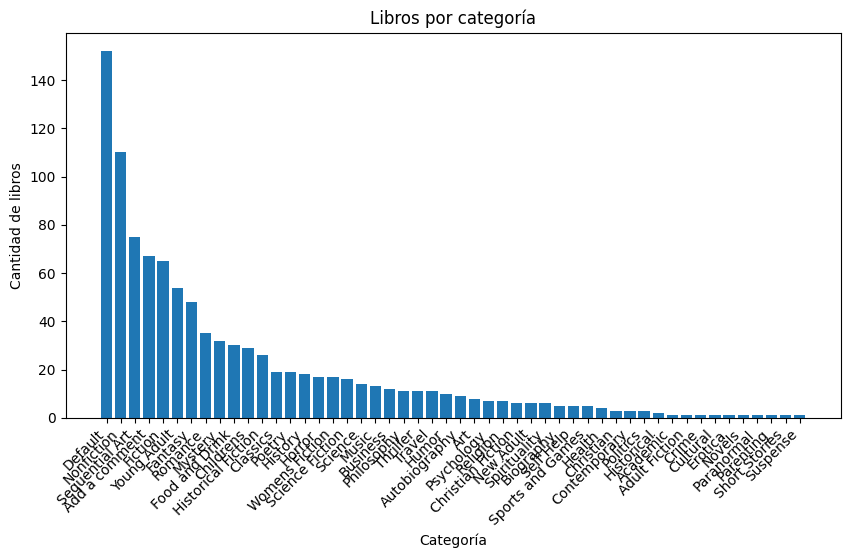

In [ ]:
import sqlite3 
import pandas as pd

# para crear graficos
import matplotlib.pyplot as plt

conn = sqlite3.connect("libros.db")

sql = """
SELECT c.name AS category, COUNT(*) AS total_books
FROM books b
JOIN categories c ON b.category_id = c.id
GROUP BY c.id
ORDER BY total_books DESC;
"""

df = pd.read_sql_query(sql, conn)
conn.close()

print(df.head())


# figure() es un metodo para crear un lienzo en blanco
plt.figure(figsize=(10, 5))  # tamaño del gráfico figsize() se mide en pulgadas, no pixeles


# bar() dibuja un grafico de barras verticales
plt.bar(df["category"], df["total_books"])


# xticks() configura las etiquetas del eje x, rotation rota el texto, para que no se choquen o esten superpuestos
plt.xticks(rotation=45, ha="right")  # rotar etiquetas si son largas


# xlabel() y y label() Agrega etiquetas a los ejes x e y, normalmente para explicar que se muestra
plt.xlabel("Categoría")
plt.ylabel("Cantidad de libros")

# title() agrega una etiqueta, que va a ser tipo titulo, al grafico
plt.title("Libros por categoría")

# renderiza y muestra el grafico
plt.show()


Matplotlib is building the font cache; this may take a moment.


         category  total_books
0         Default          152
1      Nonfiction          110
2  Sequential Art           75
3   Add a comment           67
4         Fiction           65


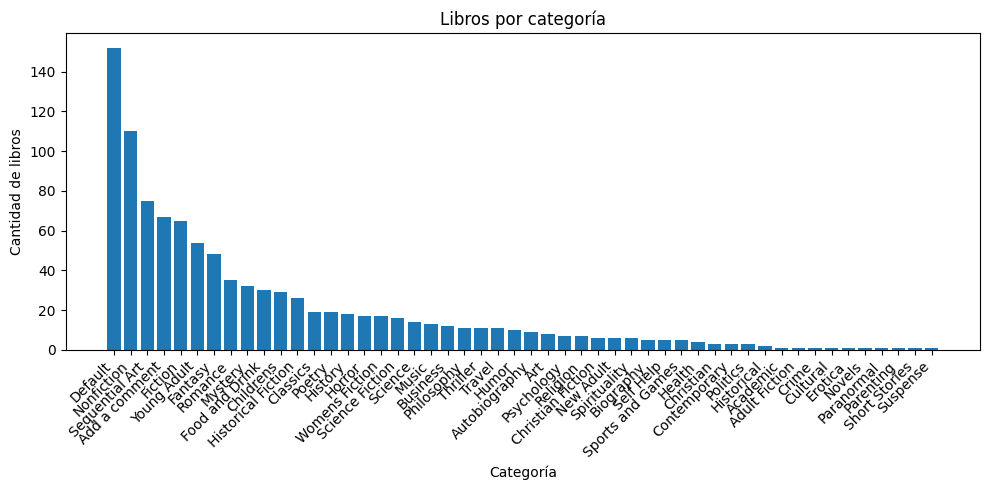

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("libros.db")

sql = """
SELECT c.name AS category, COUNT(*) AS total_books
FROM books b
JOIN categories c ON b.category_id = c.id
GROUP BY c.id
ORDER BY total_books DESC;
"""

df = pd.read_sql_query(sql, conn)
conn.close()

print(df.head())


# figure() es un metodo para crear un lienzo en blanco
plt.figure(figsize=(10, 5))  # tamaño del gráfico figsize() se mide en pulgadas, no pixeles


# bar() dibuja un grafico de barras verticales
plt.bar(df["category"], df["total_books"])


# xticks() configura las etiquetas del eje x, rotation rota el texto, para que no se choquen o esten superpuestos
plt.xticks(rotation=45, ha="right")  # rotar etiquetas si son largas


# xlabel() y y label() Agrega etiquetas a los ejes x e y, normalmente para explicar que se muestra
plt.xlabel("Categoría")
plt.ylabel("Cantidad de libros")

# title() agrega una etiqueta, que va a ser tipo titulo, al grafico
plt.title("Libros por categoría")



# tight_layaut() ajusta automaticamente los margenes, obtiene todo el grafico, calcula cuanto espacio necesita cada cosa, y reajusta subposiciones para que todo entre bien dentro del grafico
plt.tight_layout()  # para que no se corte nada

# renderiza y muestra el grafico
plt.show()
